# Latent Space Interpolation Test

This notebook tests the quality of the latent space by measuring:
1. **SMOOTHNESS**: Outputs change gradually between z1 and z2
2. **VALIDITY**: All intermediate shapes have valid meshes
3. **CONNECTIVITY**: All intermediate shapes are connected (1 component)
4. **NO HOLES**: No z values along the path produce garbage

In [102]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import ndimage
from scipy.spatial import cKDTree
from skimage import measure
import trimesh

from util.checkpointing import load_yaml_and_drop_keys
from util.misc import get_model
from models.net_w_partials import NetWithPartials
from util.visualization.utils_mesh import get_watertight_mesh_for_latent

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Configuration

In [ ]:
# ============================================================
# CONFIGURATION - Modify these settings
# ============================================================

# Paths to checkpoints
CHECKPOINT_1000 = '../checkpoints/cond_wire/2026_01_27__21_45_02-m8eyb37q/2026_01_27__21_45_02-m8eyb37q-model.pt'
CHECKPOINT_3000 = '../checkpoints/cond_wire/2026_01_27__21_58_20-bnsrxi2p/2026_01_27__21_58_20-bnsrxi2p-model.pt'

# Test parameters
N_PAIRS = 5          # Number of random z pairs to test
N_STEPS = 10         # Number of interpolation steps per pair
RESOLUTION = 48      # Mesh resolution (higher = slower but more accurate)

# Z range - IMPORTANT: must match training range!
Z_MIN = -0.1
Z_MAX = 0.1

# Random seed - set to None for random, or an INTEGER for reproducibility
SEED = None  # Random each run (use e.g. 42 for reproducibility)

## Helper Functions

In [104]:
def count_mesh_components(vertices, faces):
    """Count connected components in a mesh using trimesh."""
    if len(vertices) == 0 or len(faces) == 0:
        return 0
    mesh = trimesh.Trimesh(vertices=vertices, faces=faces)
    components = mesh.split(only_watertight=False)
    return len(components)


def compute_mesh_volume(vertices, faces):
    """Compute volume of mesh."""
    if len(vertices) == 0 or len(faces) == 0:
        return 0.0
    try:
        mesh = trimesh.Trimesh(vertices=vertices, faces=faces)
        if mesh.is_watertight:
            return abs(mesh.volume)
        else:
            return abs(mesh.convex_hull.volume) * 0.5
    except:
        return 0.0


def interpolate_z(z1, z2, alpha):
    """Linear interpolation between two z vectors."""
    return (1 - alpha) * z1 + alpha * z2


def compute_shape_difference(verts1, faces1, verts2, faces2):
    """Compute Chamfer distance between two shapes."""
    if len(verts1) == 0 or len(verts2) == 0:
        return float('inf')
    
    n_sample = min(1000, len(verts1), len(verts2))
    idx1 = np.random.choice(len(verts1), n_sample, replace=len(verts1) < n_sample)
    idx2 = np.random.choice(len(verts2), n_sample, replace=len(verts2) < n_sample)
    v1, v2 = verts1[idx1], verts2[idx2]
    
    tree1, tree2 = cKDTree(v1), cKDTree(v2)
    d1, _ = tree2.query(v1)
    d2, _ = tree1.query(v2)
    
    return np.mean(d1) + np.mean(d2)


def generate_mesh_for_z(netp, z, bounds, resolution=64):
    """Generate mesh for a given z latent vector."""
    try:
        verts, faces = get_watertight_mesh_for_latent(
            netp.f_, netp.params, z, bounds,
            mc_resolution=resolution,
            device=device,
            chunks=1,
            level=0,
            surpress_watertight=True
        )
        return verts, faces
    except Exception as e:
        return np.array([]), np.array([])

## Load Both Models (Original + Fine-tuned)

In [105]:
# Load ORIGINAL model
config_path = Path('../checkpoints/GINN-config.yml')
model_path = Path('../checkpoints/GINN-model.pt')

config = load_yaml_and_drop_keys(str(config_path), keys_to_drop=[])
print(f"Config layers: {config['model'].get('layers')}")

model_original = get_model(**config['model'], use_legacy_gabor=True)
model_original.load_state_dict(torch.load(model_path, map_location=device))
model_original = model_original.to(device)
model_original.eval()
print(f"✓ Loaded ORIGINAL model from {model_path}")

# Load 1000 EPOCH fine-tuned model
config_1000 = load_yaml_and_drop_keys(str(config_path), keys_to_drop=[])
model_1000 = get_model(**config_1000['model'], use_legacy_gabor=True)
checkpoint = torch.load(CHECKPOINT_1000, map_location=device)
if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
    model_1000.load_state_dict(checkpoint['state_dict'])
else:
    model_1000.load_state_dict(checkpoint)
model_1000 = model_1000.to(device)
model_1000.eval()
print(f"✓ Loaded 1000 EPOCH model from {CHECKPOINT_1000}")

# Load 3000 EPOCH fine-tuned model
config_3000 = load_yaml_and_drop_keys(str(config_path), keys_to_drop=[])
model_3000 = get_model(**config_3000['model'], use_legacy_gabor=True)
checkpoint = torch.load(CHECKPOINT_3000, map_location=device)
if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
    model_3000.load_state_dict(checkpoint['state_dict'])
else:
    model_3000.load_state_dict(checkpoint)
model_3000 = model_3000.to(device)
model_3000.eval()
print(f"✓ Loaded 3000 EPOCH model from {CHECKPOINT_3000}")

# Create NetWithPartials for all models
netp_original = NetWithPartials.create_from_model(model_original, config['nz'], config['nx'])
netp_1000 = NetWithPartials.create_from_model(model_1000, config['nz'], config['nx'])
netp_3000 = NetWithPartials.create_from_model(model_3000, config['nz'], config['nx'])
bounds = torch.from_numpy(np.load('../GINN/simJEB/data/bounds.npy')).float().to(device)

print(f"\n  nz={config['nz']}, nx={config['nx']}")
print(f"  z range = [{Z_MIN}, {Z_MAX}]")

Config layers: [128, 128, 128]
✓ Loaded ORIGINAL model from ..\checkpoints\GINN-model.pt
✓ Loaded 1000 EPOCH model from ../checkpoints/cond_wire/2026_01_27__21_45_02-m8eyb37q/2026_01_27__21_45_02-m8eyb37q-model.pt
✓ Loaded 3000 EPOCH model from ../checkpoints/cond_wire/2026_01_27__21_58_20-bnsrxi2p/2026_01_27__21_58_20-bnsrxi2p-model.pt

  nz=2, nx=3
  z range = [0.0, 0.1]


C:\Users\chukw\AppData\Local\Temp\ipykernel_41496\2964455947.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_original.load_state_dict(torch.load(model_path, map_lo

## Test Softplus Activation

The current models use **WIRE** (Gabor wavelet activation). Let's try creating a model with **Softplus** activation to compare.

In [106]:
# Create a SOFTPLUS model (randomly initialized - for comparison)
# Note: This will NOT have trained weights - it's randomly initialized!

# Softplus uses 'cond_general_net' with 'activation: softplus'
softplus_config = {
    'model_str': 'cond_general_net',
    'nx': config['nx'],
    'nz': config['nz'],
    'layers': [128, 128, 128],  # Same hidden layers as WIRE
    'activation': 'softplus',
}

model_softplus = get_model(**softplus_config)
model_softplus = model_softplus.to(device)
model_softplus.eval()

# Create NetWithPartials for softplus so we can run interpolation tests
netp_softplus = NetWithPartials.create_from_model(model_softplus, config['nz'], config['nx'])

print("=" * 70)
print("MODEL ARCHITECTURE COMPARISON")
print("=" * 70)
print(f"\n1. WIRE (Original - TRAINED):")
print(f"   - Activation: Gabor wavelet (complex sinusoid * Gaussian)")
print(f"   - Parameters: {sum(p.numel() for p in model_original.parameters()):,}")

print(f"\n2. Softplus (RANDOM weights - NOT trained):")
print(f"   - Activation: log(1 + exp(βx)) with β=10")
print(f"   - Parameters: {sum(p.numel() for p in model_softplus.parameters()):,}")

print("\n" + "=" * 70)
print("⚠️  NOTE: The softplus model has RANDOM weights!")
print("   Results will show baseline behavior of an untrained network.")
print("   To properly compare, you would need to TRAIN a softplus model.")
print("=" * 70)

# Show a quick output comparison
z_test = torch.rand(config['nz'], device=device) * 0.1
x_test = torch.rand(100, config['nx'], device=device)

with torch.no_grad():
    z_expanded = z_test.unsqueeze(0).expand(100, -1)
    out_wire = model_original(x_test, z_expanded)
    out_softplus = model_softplus(x_test, z_expanded)

print(f"\nOutput statistics for same input:")
print(f"  WIRE:     mean={out_wire.mean():.4f}, std={out_wire.std():.4f}, range=[{out_wire.min():.4f}, {out_wire.max():.4f}]")
print(f"  Softplus: mean={out_softplus.mean():.4f}, std={out_softplus.std():.4f}, range=[{out_softplus.min():.4f}, {out_softplus.max():.4f}]")

MODEL ARCHITECTURE COMPARISON

1. WIRE (Original - TRAINED):
   - Activation: Gabor wavelet (complex sinusoid * Gaussian)
   - Parameters: 67,713

2. Softplus (RANDOM weights - NOT trained):
   - Activation: log(1 + exp(βx)) with β=10
   - Parameters: 33,921

⚠️  NOTE: The softplus model has RANDOM weights!
   Results will show baseline behavior of an untrained network.
   To properly compare, you would need to TRAIN a softplus model.

Output statistics for same input:
  WIRE:     mean=0.1835, std=0.0890, range=[-0.0539, 0.4782]
  Softplus: mean=0.0267, std=0.0043, range=[0.0167, 0.0331]


## Run Interpolation Test

In [107]:
# Generate random z pairs (same for both models for fair comparison)
import time

if SEED is not None:
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    print(f"Using fixed seed: {SEED}")
else:
    # Random seed based on time
    random_seed = int(time.time()) % 100000
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)
    print(f"Using random seed: {random_seed}")

nz = config['nz']
z_pairs = []
for i in range(N_PAIRS):
    z1 = torch.rand(nz, device=device) * (Z_MAX - Z_MIN) + Z_MIN
    z2 = torch.rand(nz, device=device) * (Z_MAX - Z_MIN) + Z_MIN
    z_pairs.append((z1, z2))

print(f"Testing {N_PAIRS} z pairs with {N_STEPS} interpolation steps each")
print(f"z range: [{Z_MIN}, {Z_MAX}]")
print(f"Will test BOTH models on the same z pairs for fair comparison")

Using random seed: 56656
Testing 5 z pairs with 10 interpolation steps each
z range: [0.0, 0.1]
Will test BOTH models on the same z pairs for fair comparison


In [108]:
def run_interpolation_tests(netp, model_name):
    """Run interpolation tests for a model."""
    all_results = []
    
    for pair_idx, (z1, z2) in enumerate(tqdm(z_pairs, desc=f"Testing {model_name}")):
        alphas = np.linspace(0, 1, N_STEPS)
        
        results = {
            'alphas': alphas.tolist(),
            'n_components': [],
            'volumes': [],
            'valid': [],
            'smoothness_scores': [],
            'meshes': []
        }
        
        prev_verts, prev_faces = None, None
        
        for step_idx, alpha in enumerate(alphas):
            z = interpolate_z(z1, z2, alpha)
            verts, faces = generate_mesh_for_z(netp, z, bounds, RESOLUTION)
            
            n_comp = count_mesh_components(verts, faces)
            vol = compute_mesh_volume(verts, faces)
            is_valid = len(verts) > 0
            
            results['n_components'].append(n_comp)
            results['volumes'].append(vol)
            results['valid'].append(is_valid)
            results['meshes'].append((verts, faces))
            
            if step_idx == 0:
                results['smoothness_scores'].append(0.0)
            elif prev_verts is not None and is_valid and len(prev_verts) > 0:
                diff = compute_shape_difference(prev_verts, prev_faces, verts, faces)
                results['smoothness_scores'].append(diff)
            else:
                results['smoothness_scores'].append(float('inf'))
            
            if is_valid:
                prev_verts, prev_faces = verts, faces
        
        all_results.append(results)
    
    return all_results

# Run tests on ALL FOUR models
print("=" * 70)
print("Running tests on ORIGINAL model...")
print("=" * 70)
results_original = run_interpolation_tests(netp_original, "Original")

print("\n" + "=" * 70)
print("Running tests on 1000 EPOCH model...")
print("=" * 70)
results_1000 = run_interpolation_tests(netp_1000, "1000 Epoch")

print("\n" + "=" * 70)
print("Running tests on 3000 EPOCH model...")
print("=" * 70)
results_3000 = run_interpolation_tests(netp_3000, "3000 Epoch")

print("\n" + "=" * 70)
print("Running tests on SOFTPLUS model (random weights)...")
print("=" * 70)
results_softplus = run_interpolation_tests(netp_softplus, "Softplus")

print("\n✓ All tests complete!")

Running tests on ORIGINAL model...


Testing Original:   0%|          | 0/5 [00:00<?, ?it/s]


Running tests on 1000 EPOCH model...


Testing 1000 Epoch:   0%|          | 0/5 [00:00<?, ?it/s]


Running tests on 3000 EPOCH model...


Testing 3000 Epoch:   0%|          | 0/5 [00:00<?, ?it/s]


Running tests on SOFTPLUS model (random weights)...


Testing Softplus:   0%|          | 0/5 [00:00<?, ?it/s]


✓ All tests complete!


## Analyze Results

In [109]:
def analyze_path_results(results):
    """Analyze interpolation path results."""
    n_steps = len(results['alphas'])
    
    validity_rate = sum(results['valid']) / n_steps
    
    valid_comps = [c for c, v in zip(results['n_components'], results['valid']) if v and c > 0]
    connected_rate = sum(1 for c in valid_comps if c == 1) / len(valid_comps) if valid_comps else 0
    
    n_holes = sum(1 for v in results['valid'] if not v)
    
    smoothness = [s for s in results['smoothness_scores'][1:] if s != float('inf')]
    avg_smoothness = np.mean(smoothness) if smoothness else float('inf')
    max_smoothness = np.max(smoothness) if smoothness else float('inf')
    
    n_discontinuities = sum(1 for s in results['smoothness_scores'][1:] if s == float('inf'))
    
    valid_volumes = [v for v, is_valid in zip(results['volumes'], results['valid']) if is_valid and v > 0]
    volume_cv = np.std(valid_volumes) / np.mean(valid_volumes) if valid_volumes and np.mean(valid_volumes) > 0 else float('inf')
    
    return {
        'validity_rate': validity_rate,
        'connected_rate': connected_rate,
        'n_holes': n_holes,
        'n_discontinuities': n_discontinuities,
        'avg_smoothness': avg_smoothness,
        'max_smoothness': max_smoothness,
        'volume_cv': volume_cv,
    }

# Analyze all FOUR models
analyses_original = [analyze_path_results(r) for r in results_original]
analyses_1000 = [analyze_path_results(r) for r in results_1000]
analyses_3000 = [analyze_path_results(r) for r in results_3000]
analyses_softplus = [analyze_path_results(r) for r in results_softplus]

# Print side-by-side comparison
print("=" * 170)
print("SIDE-BY-SIDE COMPARISON: Per-Pair Results")
print("=" * 170)
print(f"{'Pair':<6} | {'ORIGINAL':<38} | {'1000 EPOCH':<38} | {'3000 EPOCH':<38} | {'SOFTPLUS (random)':<38}")
print("-" * 170)
for i in range(N_PAIRS):
    ao, a1, a3, asp = analyses_original[i], analyses_1000[i], analyses_3000[i], analyses_softplus[i]
    print(f"Pair {i+1:<2} | Valid:{ao['validity_rate']*100:3.0f}% Conn:{ao['connected_rate']*100:3.0f}% Holes:{ao['n_holes']} | "
          f"Valid:{a1['validity_rate']*100:3.0f}% Conn:{a1['connected_rate']*100:3.0f}% Holes:{a1['n_holes']} | "
          f"Valid:{a3['validity_rate']*100:3.0f}% Conn:{a3['connected_rate']*100:3.0f}% Holes:{a3['n_holes']} | "
          f"Valid:{asp['validity_rate']*100:3.0f}% Conn:{asp['connected_rate']*100:3.0f}% Holes:{asp['n_holes']}")

SIDE-BY-SIDE COMPARISON: Per-Pair Results
Pair   | ORIGINAL                               | 1000 EPOCH                             | 3000 EPOCH                             | SOFTPLUS (random)                     
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Pair 1  | Valid:100% Conn:100% Holes:0 | Valid:100% Conn:  0% Holes:0 | Valid:100% Conn:  0% Holes:0 | Valid:  0% Conn:  0% Holes:10
Pair 2  | Valid:100% Conn:100% Holes:0 | Valid:100% Conn: 40% Holes:0 | Valid:100% Conn:  0% Holes:0 | Valid:  0% Conn:  0% Holes:10
Pair 3  | Valid:100% Conn:100% Holes:0 | Valid:100% Conn:  0% Holes:0 | Valid:100% Conn:  0% Holes:0 | Valid:  0% Conn:  0% Holes:10
Pair 4  | Valid:100% Conn:100% Holes:0 | Valid:100% Conn:  0% Holes:0 | Valid:100% Conn:  0% Holes:0 | Valid:  0% Conn:  0% Holes:10
Pair 5  | Valid:100% Conn:100% Holes:0 | Valid:100% Conn:  0% Holes:0 | Valid:100% C

In [110]:
def compute_aggregate(analyses, name):
    """Compute aggregate metrics."""
    avg_validity = np.mean([a['validity_rate'] for a in analyses])
    avg_connectivity = np.mean([a['connected_rate'] for a in analyses])
    total_holes = sum(a['n_holes'] for a in analyses)
    total_discontinuities = sum(a['n_discontinuities'] for a in analyses)
    
    valid_smoothness = [a['avg_smoothness'] for a in analyses if a['avg_smoothness'] != float('inf')]
    avg_smoothness = np.mean(valid_smoothness) if valid_smoothness else float('inf')
    
    valid_max = [a['max_smoothness'] for a in analyses if a['max_smoothness'] != float('inf')]
    max_smoothness = max(valid_max) if valid_max else float('inf')
    
    valid_cv = [a['volume_cv'] for a in analyses if a['volume_cv'] != float('inf')]
    avg_volume_cv = np.mean(valid_cv) if valid_cv else float('inf')
    
    return {
        'name': name,
        'validity': avg_validity,
        'connectivity': avg_connectivity,
        'holes': total_holes,
        'discontinuities': total_discontinuities,
        'smoothness': avg_smoothness,
        'max_smoothness': max_smoothness,
        'volume_cv': avg_volume_cv
    }

agg_original = compute_aggregate(analyses_original, "ORIGINAL")
agg_1000 = compute_aggregate(analyses_1000, "1000 EPOCH")
agg_3000 = compute_aggregate(analyses_3000, "3000 EPOCH")
agg_softplus = compute_aggregate(analyses_softplus, "SOFTPLUS")

# Print comparison table
print("\n" + "=" * 140)
print("AGGREGATE COMPARISON (4 Models)")
print("=" * 140)
print(f"{'Metric':<20} | {'ORIGINAL':<18} | {'1000 EPOCH':<18} | {'3000 EPOCH':<18} | {'SOFTPLUS':<18} | {'Best':<15}")
print("-" * 140)

metrics = [
    ('Validity %', 'validity', True),
    ('Connectivity %', 'connectivity', True),
    ('Holes', 'holes', False),
    ('Discontinuities', 'discontinuities', False),
    ('Avg Smoothness', 'smoothness', False),
    ('Volume CV', 'volume_cv', False),
]

for label, key, higher_better in metrics:
    vo, v1, v3, vsp = agg_original[key], agg_1000[key], agg_3000[key], agg_softplus[key]
    
    if key in ['validity', 'connectivity']:
        so, s1, s3, ssp = f"{vo*100:.1f}%", f"{v1*100:.1f}%", f"{v3*100:.1f}%", f"{vsp*100:.1f}%"
    elif key in ['holes', 'discontinuities']:
        so, s1, s3, ssp = f"{int(vo)}", f"{int(v1)}", f"{int(v3)}", f"{int(vsp)}"
    else:
        so = f"{vo:.4f}" if vo != float('inf') else "inf"
        s1 = f"{v1:.4f}" if v1 != float('inf') else "inf"
        s3 = f"{v3:.4f}" if v3 != float('inf') else "inf"
        ssp = f"{vsp:.4f}" if vsp != float('inf') else "inf"
    
    # Find best
    vals = [('Original', vo), ('1000ep', v1), ('3000ep', v3), ('Softplus', vsp)]
    valid_vals = [(n, v) for n, v in vals if v != float('inf')]
    if not valid_vals:
        best = "N/A"
    elif higher_better:
        best = max(valid_vals, key=lambda x: x[1])[0] + " 🏆"
    else:
        best = min(valid_vals, key=lambda x: x[1])[0] + " 🏆"
    
    print(f"{label:<20} | {so:<18} | {s1:<18} | {s3:<18} | {ssp:<18} | {best:<15}")

print("=" * 140)

# Critical failure check
print("\n" + "=" * 140)
print("CRITICAL ANALYSIS")
print("=" * 140)

failures = []
if agg_original['connectivity'] < 0.5:
    failures.append("Original")
if agg_1000['connectivity'] < 0.5:
    failures.append("1000 Epoch")
if agg_3000['connectivity'] < 0.5:
    failures.append("3000 Epoch")
if agg_softplus['connectivity'] < 0.5:
    failures.append("Softplus")

if failures:
    print(f"⚠️  CRITICAL CONNECTIVITY FAILURE in: {', '.join(failures)}")
    print("   These models produce mostly fragmented shapes!")
else:
    print("✓ No critical connectivity failures detected")

# Determine winner (excluding softplus since it's untrained)
print("\n📊 Scoring (trained models only - excluding random Softplus):")
scores = {'Original': 0, '1000ep': 0, '3000ep': 0}
for label, key, higher_better in metrics[:4]:
    vo, v1, v3 = agg_original[key], agg_1000[key], agg_3000[key]
    vals = [('Original', vo), ('1000ep', v1), ('3000ep', v3)]
    valid_vals = [(n, v) for n, v in vals if v != float('inf')]
    if valid_vals:
        if higher_better:
            winner = max(valid_vals, key=lambda x: x[1])[0]
        else:
            winner = min(valid_vals, key=lambda x: x[1])[0]
        scores[winner] += 1

print(f"Scores: Original={scores['Original']}, 1000ep={scores['1000ep']}, 3000ep={scores['3000ep']}")
overall_winner = max(scores, key=scores.get)
print("=" * 140)
print(f"\n🏆 OVERALL WINNER (trained models): {overall_winner}")
print("=" * 140)


AGGREGATE COMPARISON (4 Models)
Metric               | ORIGINAL           | 1000 EPOCH         | 3000 EPOCH         | SOFTPLUS           | Best           
--------------------------------------------------------------------------------------------------------------------------------------------
Validity %           | 100.0%             | 100.0%             | 100.0%             | 0.0%               | Original 🏆     
Connectivity %       | 100.0%             | 8.0%               | 0.0%               | 0.0%               | Original 🏆     
Holes                | 0                  | 0                  | 0                  | 50                 | Original 🏆     
Discontinuities      | 0                  | 0                  | 0                  | 45                 | Original 🏆     
Avg Smoothness       | 0.0587             | 0.0475             | 0.0369             | inf                | 3000ep 🏆       
Volume CV            | 0.2737             | 0.0860             | 0.0343             | in

## Visualize Side-by-Side Comparison

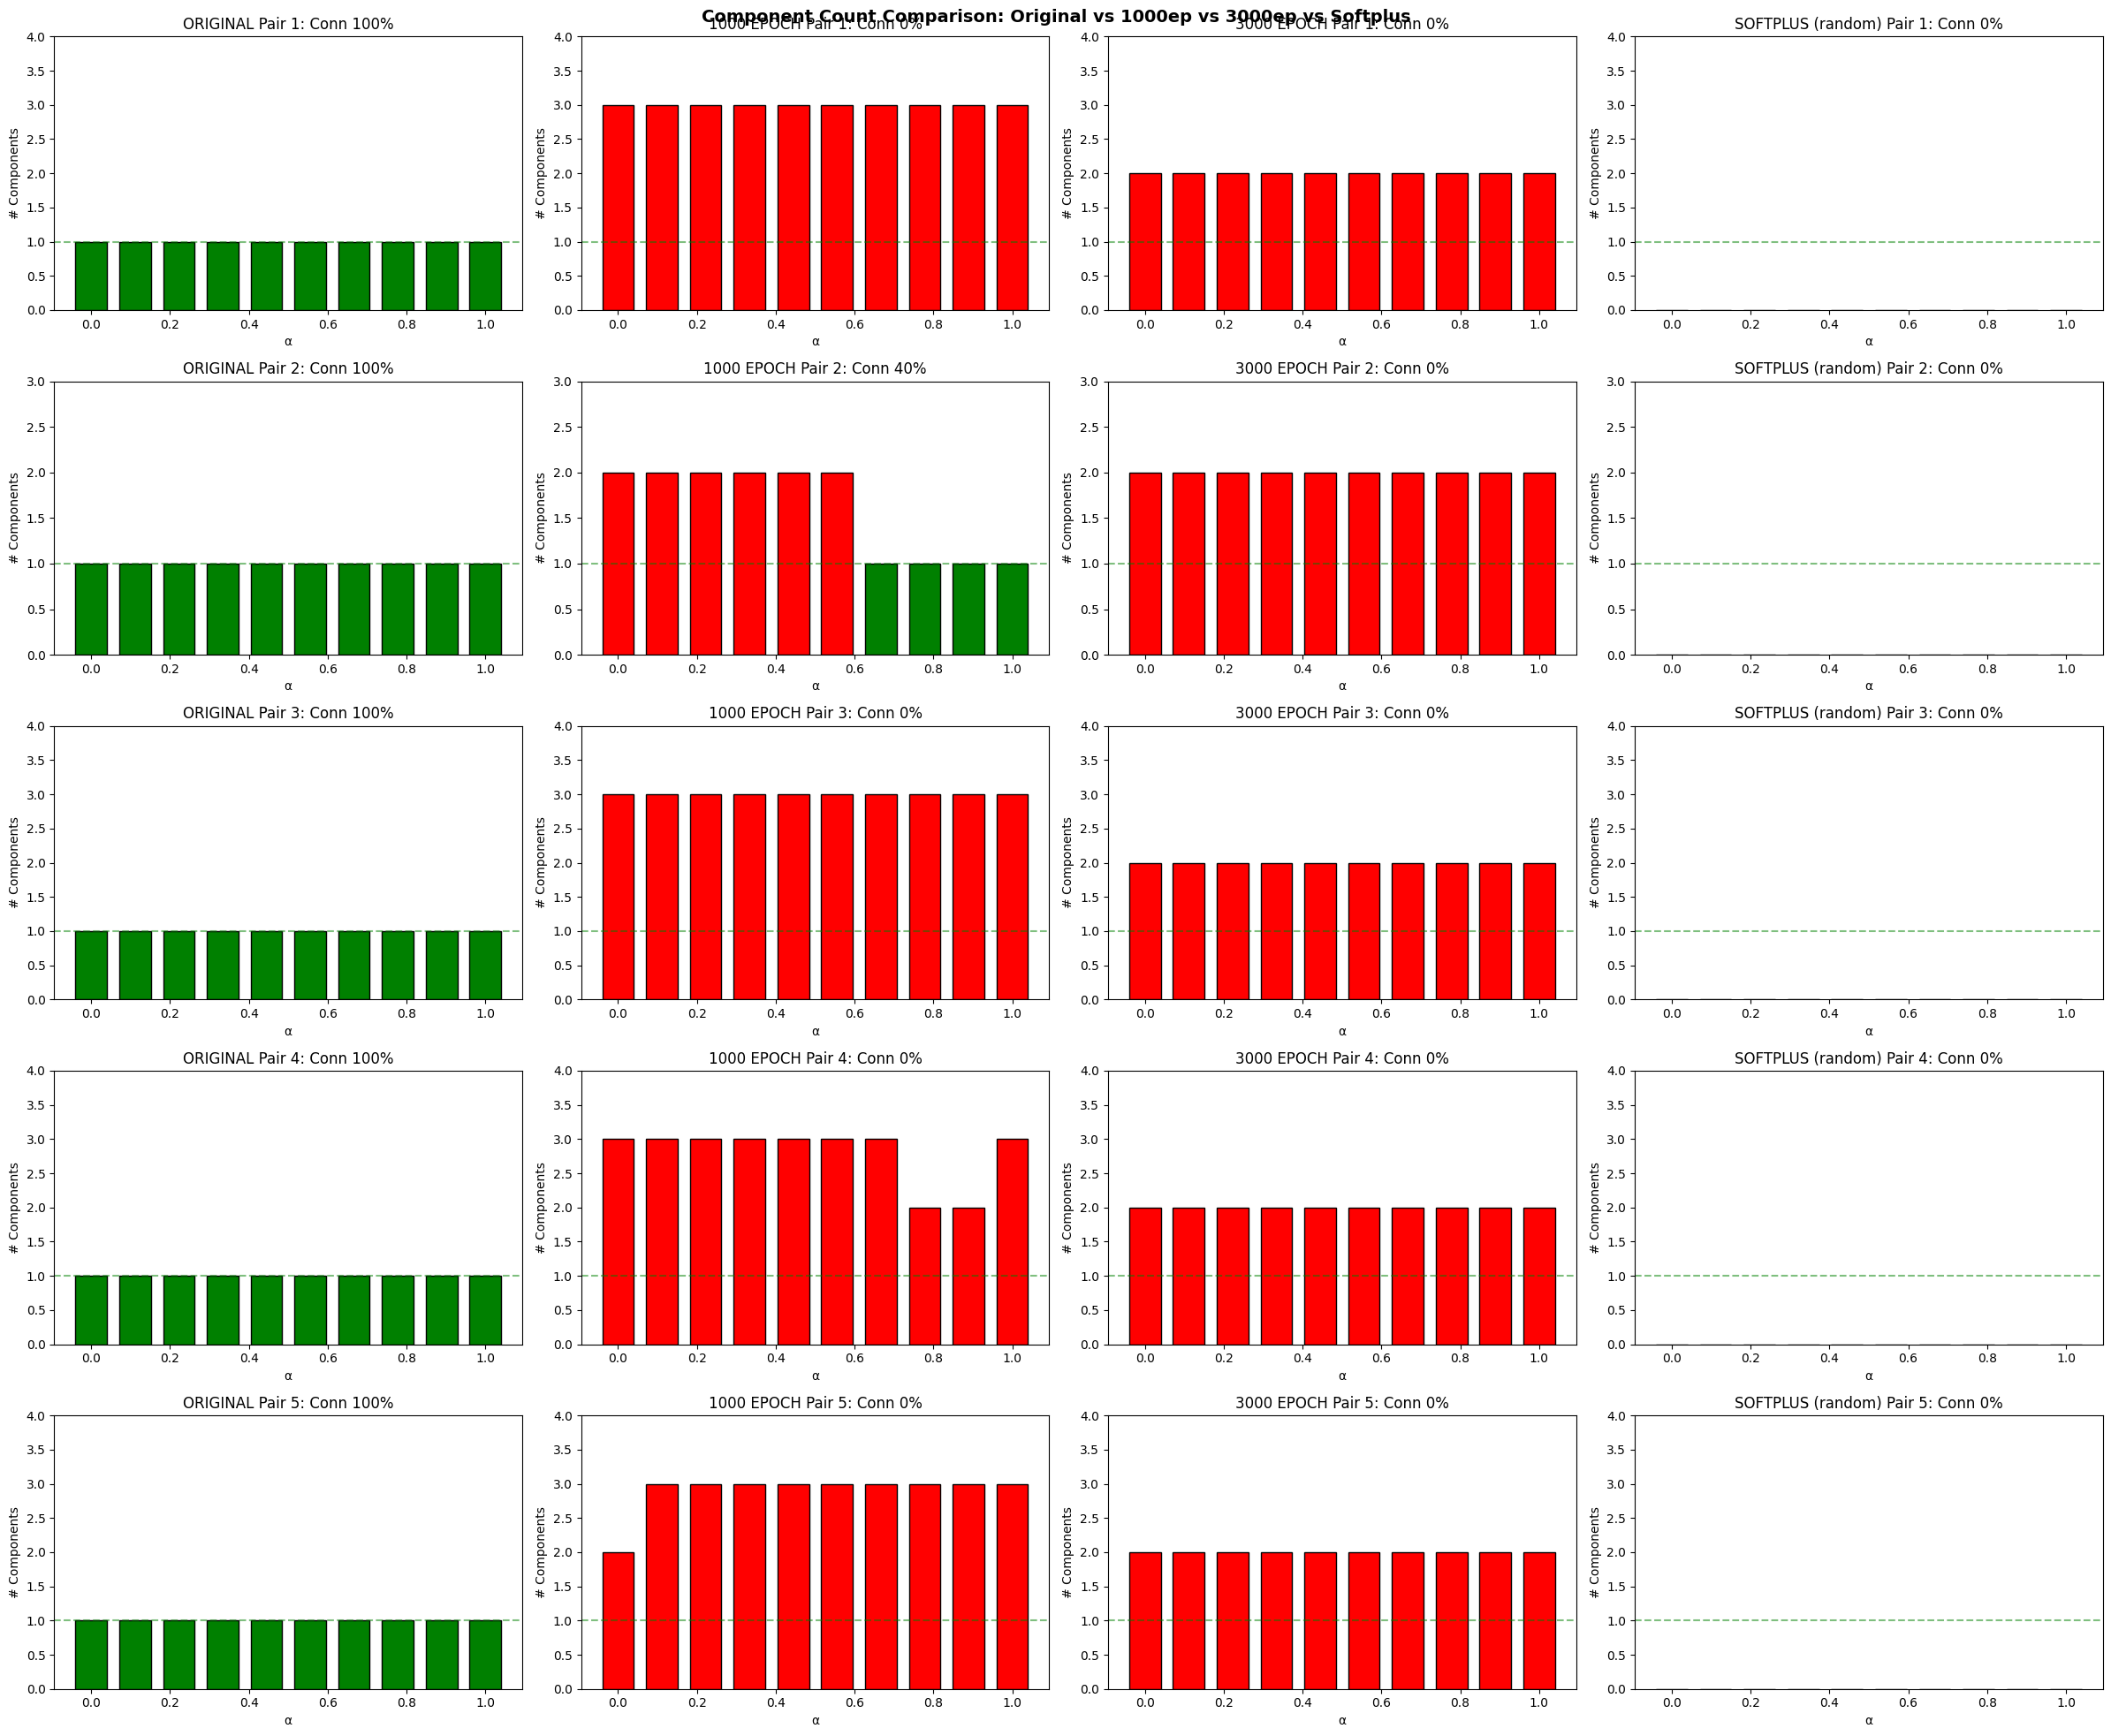

In [111]:
# Side-by-side comparison plots for all 4 models
fig, axes = plt.subplots(N_PAIRS, 4, figsize=(24, 4*N_PAIRS))
if N_PAIRS == 1:
    axes = axes.reshape(1, -1)

for pair_idx in range(N_PAIRS):
    ro = results_original[pair_idx]
    r1 = results_1000[pair_idx]
    r3 = results_3000[pair_idx]
    rsp = results_softplus[pair_idx]
    ao, a1, a3, asp = analyses_original[pair_idx], analyses_1000[pair_idx], analyses_3000[pair_idx], analyses_softplus[pair_idx]
    alphas = ro['alphas']
    
    for col, (results, analysis, name, color) in enumerate([
        (ro, ao, 'ORIGINAL', 'blue'),
        (r1, a1, '1000 EPOCH', 'orange'),
        (r3, a3, '3000 EPOCH', 'red'),
        (rsp, asp, 'SOFTPLUS (random)', 'purple')
    ]):
        ax = axes[pair_idx, col]
        colors = ['green' if c == 1 else 'red' if c > 1 else 'gray' for c in results['n_components']]
        ax.bar(alphas, results['n_components'], width=0.08, color=colors, edgecolor='black')
        ax.axhline(y=1, color='green', linestyle='--', alpha=0.5)
        ax.set_xlabel('α')
        ax.set_ylabel('# Components')
        ax.set_title(f'{name} Pair {pair_idx+1}: Conn {analysis["connected_rate"]*100:.0f}%')
        max_comp = max(max(ro['n_components']), max(r1['n_components']), max(r3['n_components']), max(rsp['n_components']) if rsp['n_components'] else 1)
        ax.set_ylim(0, max(max_comp + 1, 2))

plt.suptitle('Component Count Comparison: Original vs 1000ep vs 3000ep vs Softplus', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Shape Sequence Comparison (First Pair)

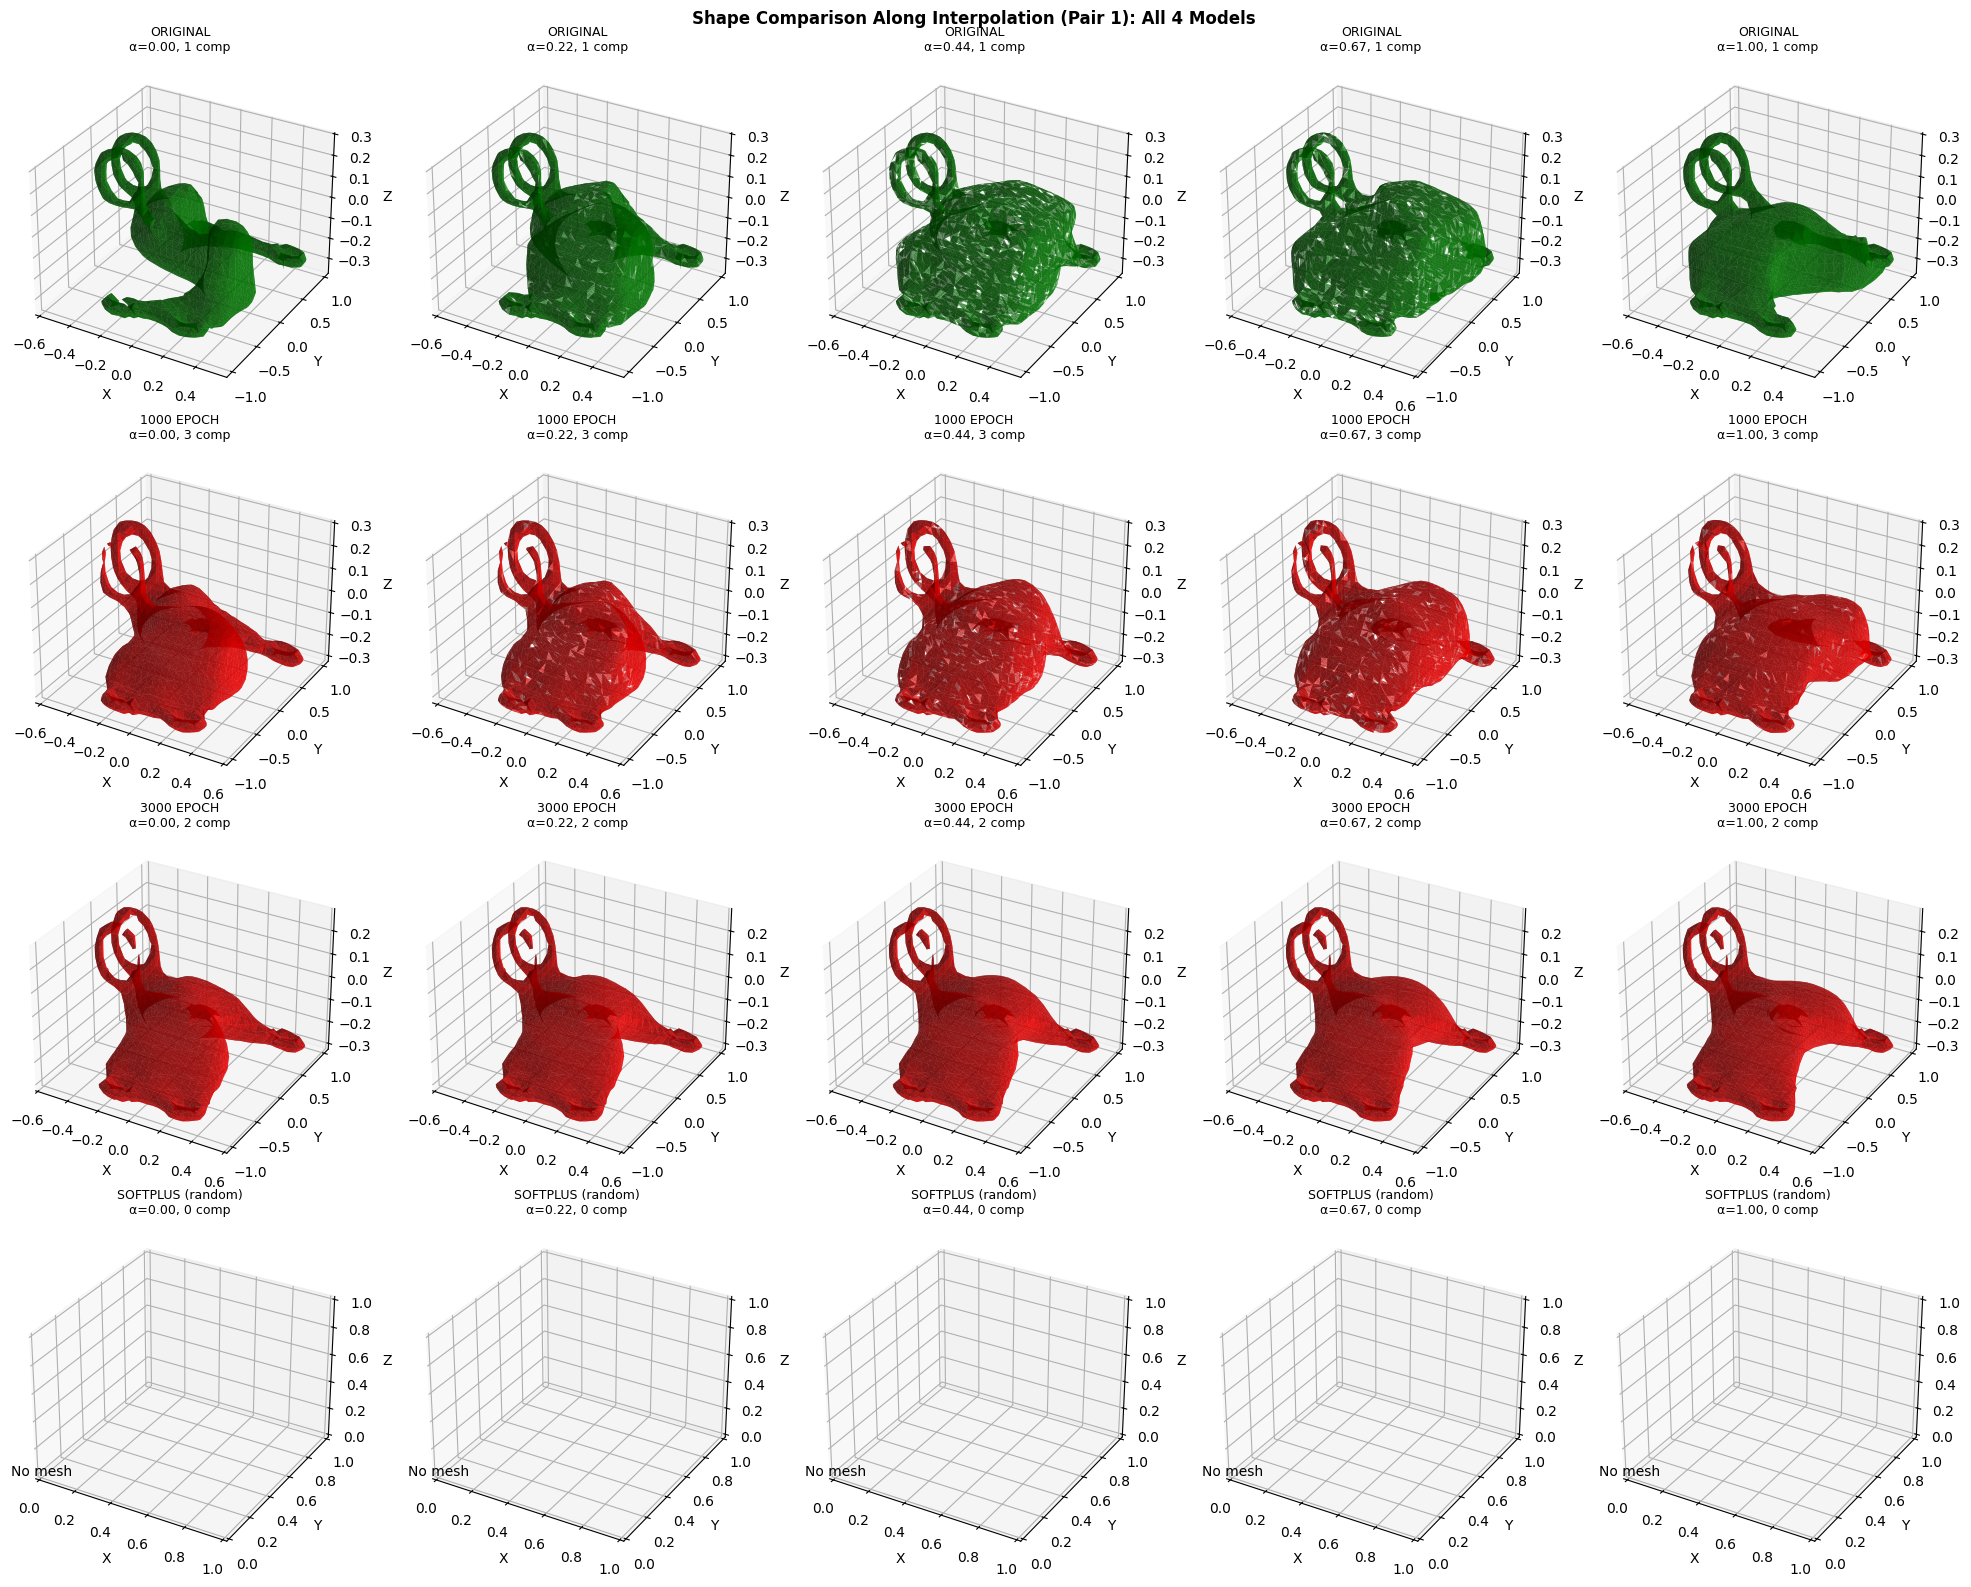

In [112]:
# Visualize shapes for the first pair - comparing all 4 models
pair_idx = 0
ro = results_original[pair_idx]
r1 = results_1000[pair_idx]
r3 = results_3000[pair_idx]
rsp = results_softplus[pair_idx]

n_show = min(5, N_STEPS)
indices = np.linspace(0, N_STEPS-1, n_show, dtype=int)

fig, axes = plt.subplots(4, n_show, figsize=(4*n_show, 16), subplot_kw={'projection': '3d'})

all_results = [
    (ro, 'ORIGINAL', 'blue'),
    (r1, '1000 EPOCH', 'orange'),
    (r3, '3000 EPOCH', 'red'),
    (rsp, 'SOFTPLUS (random)', 'purple')
]

for row, (results, model_name, base_color) in enumerate(all_results):
    for col, step_idx in enumerate(indices):
        verts, faces = results['meshes'][step_idx]
        alpha = results['alphas'][step_idx]
        n_comp = results['n_components'][step_idx]
        
        ax = axes[row, col]
        
        if len(verts) > 0 and len(faces) > 0:
            max_faces = 5000
            if len(faces) > max_faces:
                face_idx = np.random.choice(len(faces), max_faces, replace=False)
                faces_show = faces[face_idx]
            else:
                faces_show = faces
            
            color = 'green' if n_comp == 1 else 'red' if n_comp > 1 else 'gray'
            ax.plot_trisurf(verts[:, 0], verts[:, 1], verts[:, 2],
                           triangles=faces_show, alpha=0.7, color=color, edgecolor='none')
        else:
            ax.text(0, 0, 0, 'No mesh', ha='center', fontsize=10)
        
        title = f'{model_name}\nα={alpha:.2f}, {n_comp} comp'
        ax.set_title(title, fontsize=9)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')

plt.suptitle(f'Shape Comparison Along Interpolation (Pair {pair_idx+1}): All 4 Models', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Aggregate Metrics Bar Chart

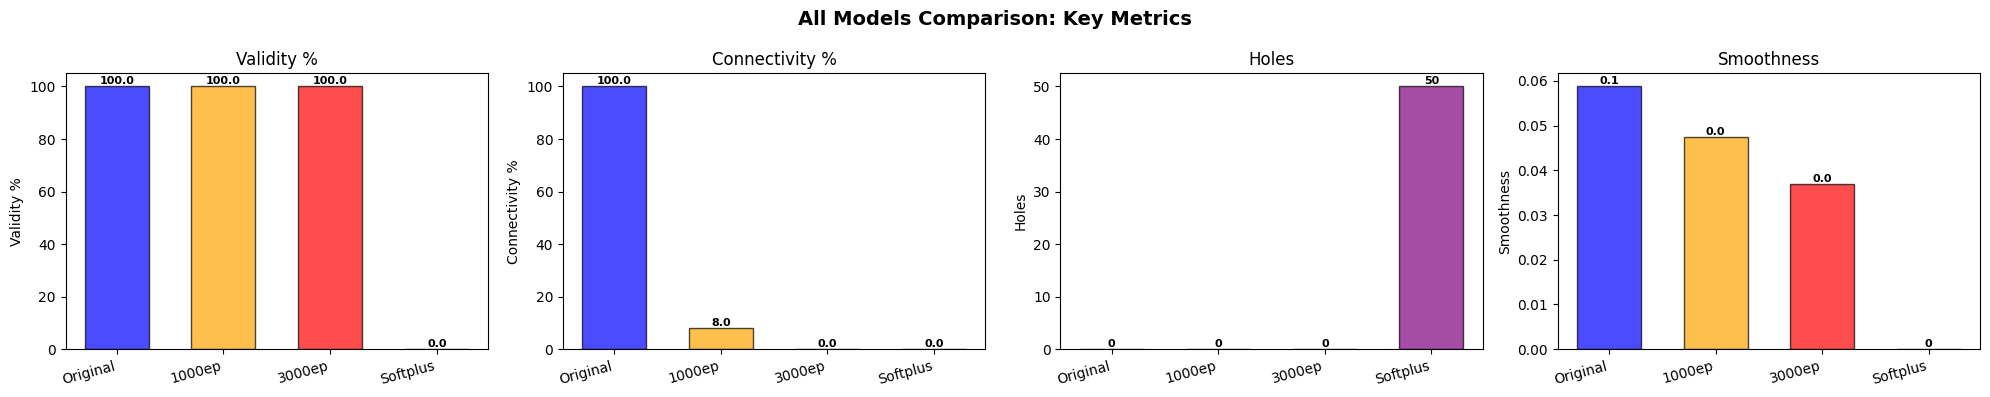


SUMMARY
Original:   100.0% connectivity, 0 holes
1000 Epoch: 8.0% connectivity, 0 holes
3000 Epoch: 0.0% connectivity, 0 holes
Softplus:   0.0% connectivity, 50 holes (RANDOM weights)


In [113]:
# Bar chart comparison for all 4 models
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

metrics_to_plot = [
    ('Validity %', agg_original['validity']*100, agg_1000['validity']*100, agg_3000['validity']*100, agg_softplus['validity']*100),
    ('Connectivity %', agg_original['connectivity']*100, agg_1000['connectivity']*100, agg_3000['connectivity']*100, agg_softplus['connectivity']*100),
    ('Holes', agg_original['holes'], agg_1000['holes'], agg_3000['holes'], agg_softplus['holes']),
    ('Smoothness', agg_original['smoothness'], agg_1000['smoothness'], agg_3000['smoothness'], agg_softplus['smoothness'] if agg_softplus['smoothness'] != float('inf') else 0),
]

x = np.arange(4)
width = 0.6

for ax, (label, vo, v1, v3, vsp) in zip(axes, metrics_to_plot):
    bars = ax.bar(x, [vo, v1, v3, vsp], width, color=['blue', 'orange', 'red', 'purple'], alpha=0.7, edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(['Original', '1000ep', '3000ep', 'Softplus'], rotation=15, ha='right')
    ax.set_ylabel(label)
    ax.set_title(label)
    
    for bar, val in zip(bars, [vo, v1, v3, vsp]):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.1f}' if isinstance(val, float) else str(val),
                ha='center', va='bottom', fontweight='bold', fontsize=8)

plt.suptitle('All Models Comparison: Key Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary
print("\n" + "=" * 90)
print("SUMMARY")
print("=" * 90)
print(f"Original:   {agg_original['connectivity']*100:.1f}% connectivity, {agg_original['holes']} holes")
print(f"1000 Epoch: {agg_1000['connectivity']*100:.1f}% connectivity, {agg_1000['holes']} holes")
print(f"3000 Epoch: {agg_3000['connectivity']*100:.1f}% connectivity, {agg_3000['holes']} holes")
print(f"Softplus:   {agg_softplus['connectivity']*100:.1f}% connectivity, {agg_softplus['holes']} holes (RANDOM weights)")
print("=" * 90)

## Mode Collapse Diagnostic

LATENT SPACE STRUCTURE DIAGNOSTIC

1. INTERPOLATION CORRELATION (distance vs α-difference):
   Should be POSITIVE: farther apart in α → more different shapes
   ORIGINAL:   0.9555
   1000 EPOCH: 0.9768
   3000 EPOCH: 0.9884
   SOFTPLUS:   N/A (no valid meshes)

2. DISTANCE COEFFICIENT OF VARIATION:
   Low CV = all pairwise distances similar = broken interpolation
   ORIGINAL:   0.3366
   1000 EPOCH: 0.2627
   3000 EPOCH: 0.1884
   SOFTPLUS:   N/A

------------------------------------------------------------------------------------------
DIAGNOSIS:
------------------------------------------------------------------------------------------
✓ 1000 EPOCH: Interpolation structure OK (corr=0.9768)
✓ 3000 EPOCH: Interpolation structure OK (corr=0.9884)
⚠️  SOFTPLUS: No valid meshes to analyze

✓ Original model has strong interpolation structure (corr=0.9555)


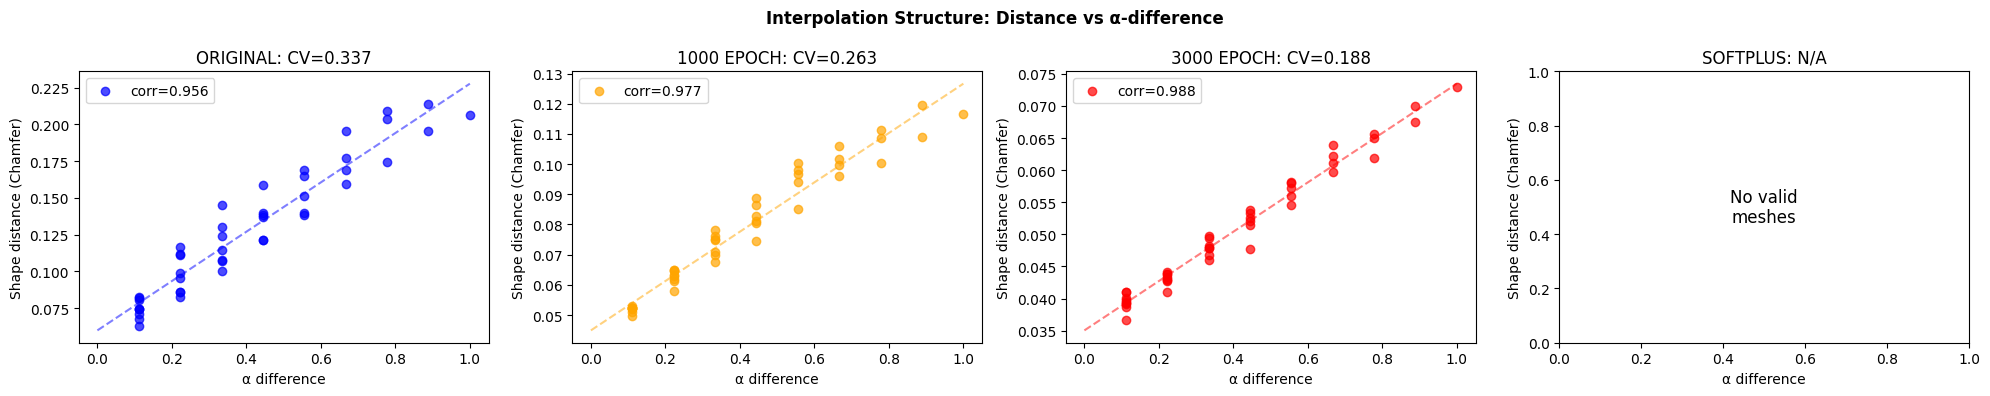

INTERPRETATION:
• Original: Positive slope = smooth interpolation ✓
• 1000 Epoch: Check if structure is preserved or degraded
• 3000 Epoch: Check if additional training helped or hurt
• Softplus: Random weights - expect poor/no valid meshes


In [114]:
# Check interpolation structure for all 4 models
print("=" * 90)
print("LATENT SPACE STRUCTURE DIAGNOSTIC")
print("=" * 90)

def analyze_interpolation_structure(results, model_name):
    """Analyze whether interpolation works correctly."""
    meshes = [(v, f, alpha) for (v, f), alpha in zip(results['meshes'], results['alphas']) if len(v) > 0]
    if len(meshes) < 3:
        return None, None, None
    
    alpha_diffs = []
    shape_dists = []
    
    for i in range(len(meshes)):
        for j in range(i+1, len(meshes)):
            v1, f1, a1 = meshes[i]
            v2, f2, a2 = meshes[j]
            alpha_diff = abs(a2 - a1)
            shape_dist = compute_shape_difference(v1, f1, v2, f2)
            alpha_diffs.append(alpha_diff)
            shape_dists.append(shape_dist)
    
    if len(alpha_diffs) < 2:
        return None, None, None
    correlation = np.corrcoef(alpha_diffs, shape_dists)[0, 1]
    dist_cv = np.std(shape_dists) / np.mean(shape_dists) if np.mean(shape_dists) > 0 else 0
    
    return correlation, dist_cv, (alpha_diffs, shape_dists)

# Analyze all models
ro, r1, r3, rsp = results_original[0], results_1000[0], results_3000[0], results_softplus[0]

orig_corr, orig_cv, orig_data = analyze_interpolation_structure(ro, "Original")
e1000_corr, e1000_cv, e1000_data = analyze_interpolation_structure(r1, "1000 Epoch")
e3000_corr, e3000_cv, e3000_data = analyze_interpolation_structure(r3, "3000 Epoch")
sp_corr, sp_cv, sp_data = analyze_interpolation_structure(rsp, "Softplus")

print(f"\n1. INTERPOLATION CORRELATION (distance vs α-difference):")
print(f"   Should be POSITIVE: farther apart in α → more different shapes")
print(f"   ORIGINAL:   {orig_corr:.4f}" if orig_corr else "   ORIGINAL:   N/A")
print(f"   1000 EPOCH: {e1000_corr:.4f}" if e1000_corr else "   1000 EPOCH: N/A")
print(f"   3000 EPOCH: {e3000_corr:.4f}" if e3000_corr else "   3000 EPOCH: N/A")
print(f"   SOFTPLUS:   {sp_corr:.4f}" if sp_corr else "   SOFTPLUS:   N/A (no valid meshes)")

print(f"\n2. DISTANCE COEFFICIENT OF VARIATION:")
print(f"   Low CV = all pairwise distances similar = broken interpolation")
print(f"   ORIGINAL:   {orig_cv:.4f}" if orig_cv else "   ORIGINAL:   N/A")
print(f"   1000 EPOCH: {e1000_cv:.4f}" if e1000_cv else "   1000 EPOCH: N/A")
print(f"   3000 EPOCH: {e3000_cv:.4f}" if e3000_cv else "   3000 EPOCH: N/A")
print(f"   SOFTPLUS:   {sp_cv:.4f}" if sp_cv else "   SOFTPLUS:   N/A")

# Diagnose
print("\n" + "-" * 90)
print("DIAGNOSIS:")
print("-" * 90)

for name, corr, cv in [("1000 EPOCH", e1000_corr, e1000_cv), ("3000 EPOCH", e3000_corr, e3000_cv), ("SOFTPLUS", sp_corr, sp_cv)]:
    if corr is None:
        print(f"⚠️  {name}: No valid meshes to analyze")
    elif cv < 0.05:
        print(f"⚠️  {name}: INTERPOLATION STRUCTURE BROKEN (CV={cv:.4f})")
    elif corr < 0.3:
        print(f"⚠️  {name}: WEAK interpolation (corr={corr:.4f})")
    else:
        print(f"✓ {name}: Interpolation structure OK (corr={corr:.4f})")

if orig_corr and orig_corr > 0.5:
    print(f"\n✓ Original model has strong interpolation structure (corr={orig_corr:.4f})")

# Visual: scatter plots for all 4
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (data, corr, cv, name, color) in zip(axes, [
    (orig_data, orig_corr, orig_cv, 'ORIGINAL', 'blue'),
    (e1000_data, e1000_corr, e1000_cv, '1000 EPOCH', 'orange'),
    (e3000_data, e3000_corr, e3000_cv, '3000 EPOCH', 'red'),
    (sp_data, sp_corr, sp_cv, 'SOFTPLUS', 'purple')
]):
    if data and len(data[0]) > 0:
        ax.scatter(data[0], data[1], alpha=0.7, c=color, label=f'corr={corr:.3f}')
        if len(data[0]) > 1:
            z = np.polyfit(data[0], data[1], 1)
            p = np.poly1d(z)
            ax.plot([0, 1], [p(0), p(1)], '--', color=color, alpha=0.5)
    else:
        ax.text(0.5, 0.5, 'No valid\nmeshes', ha='center', va='center', fontsize=12)
    ax.set_xlabel('α difference')
    ax.set_ylabel('Shape distance (Chamfer)')
    ax.set_title(f'{name}: CV={cv:.3f}' if cv else f'{name}: N/A')
    if data and len(data[0]) > 0:
        ax.legend()

plt.suptitle('Interpolation Structure: Distance vs α-difference', fontweight='bold')
plt.tight_layout()
plt.show()

print("=" * 90)
print("INTERPRETATION:")
print("=" * 90)
print("• Original: Positive slope = smooth interpolation ✓")
print("• 1000 Epoch: Check if structure is preserved or degraded")
print("• 3000 Epoch: Check if additional training helped or hurt")
print("• Softplus: Random weights - expect poor/no valid meshes")
print("=" * 90)